In [18]:
import pandas as pd
import numpy as np

# Load
df = pd.read_csv("power_consumption.csv")

# Clean column names
df.columns = df.columns.str.strip()

# Datetime
df['Datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], errors='coerce')

# Numeric conversion
df['Global_active_power'] = pd.to_numeric(df['Global_active_power'], errors='coerce')

# Drop nulls
df = df.dropna(subset=['Datetime', 'Global_active_power'])

# Set index
df.set_index('Datetime', inplace=True)

# Sort
df = df.sort_index()

# Monthly resample
ts = df['Global_active_power'].resample('M').mean()

# FINAL CLEANING
ts = ts[(ts > 0) & (ts < 5)]
ts = ts.dropna()

/tmp/ipykernel_442/479584739.py:11: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], errors='coerce')
/tmp/ipykernel_442/479584739.py:26: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  ts = df['Global_active_power'].resample('M').mean()


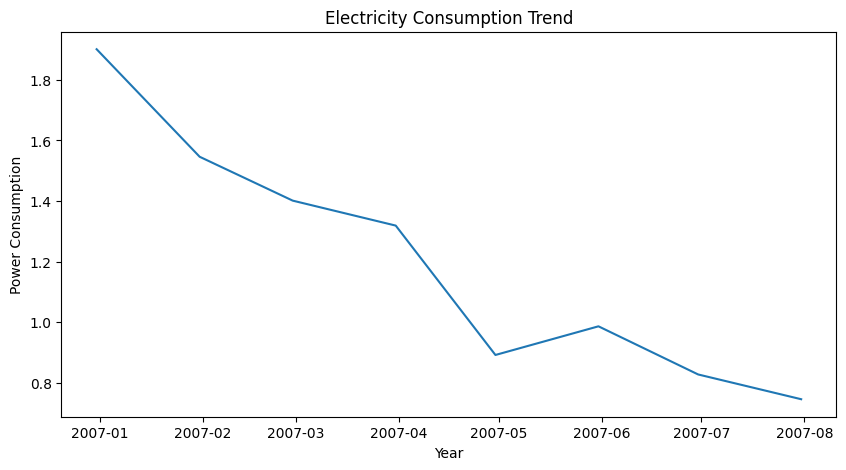

In [20]:
# Trend Plot -- Electricity consumption shows a relatively stable trend with slight fluctuations over time.
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(ts)
plt.title("Electricity Consumption Trend")
plt.xlabel("Year")
plt.ylabel("Power Consumption")
plt.show()

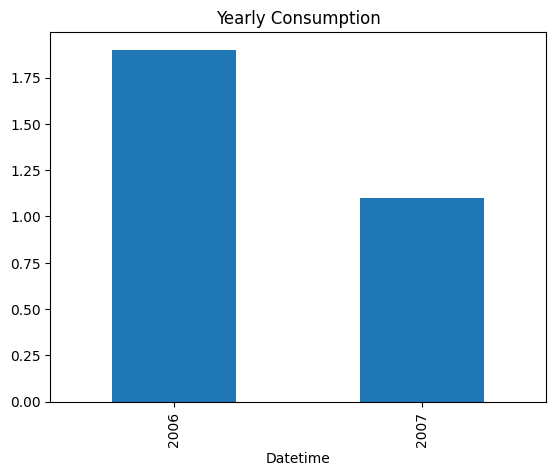

In [22]:
# Year-wise Analysis
# Yearly consumption remains consistent, indicating no major increase or decrease in demand.
ts.groupby(ts.index.year).mean().plot(kind='bar')
plt.title("Yearly Consumption")
plt.show()

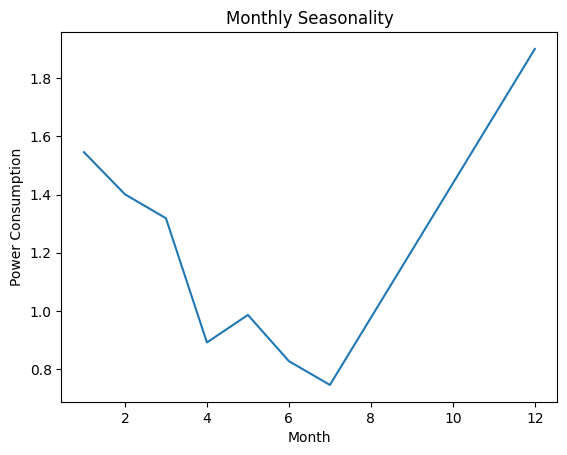

In [24]:
# Monthly Seasonality
# Monthly patterns suggest slight seasonal variation, possibly due to weather or usage behavior.
ts.groupby(ts.index.month).mean().plot()
plt.title("Monthly Seasonality")
plt.xlabel("Month")
plt.ylabel("Power Consumption")
plt.show()

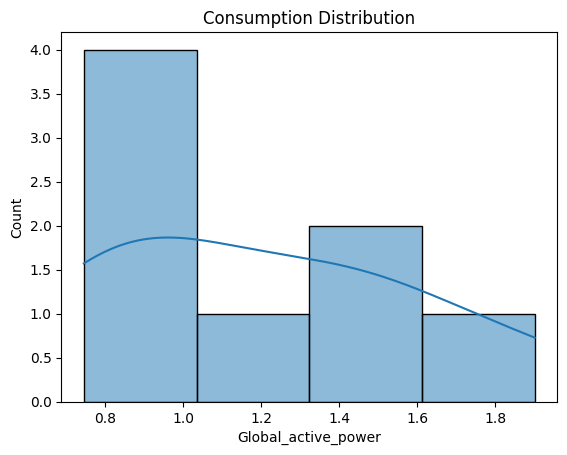

In [25]:
# Distribution Plot
# The distribution is approximately normal with most values concentrated around the average consumption.
import seaborn as sns

sns.histplot(ts, kde=True)
plt.title("Consumption Distribution")
plt.show()

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


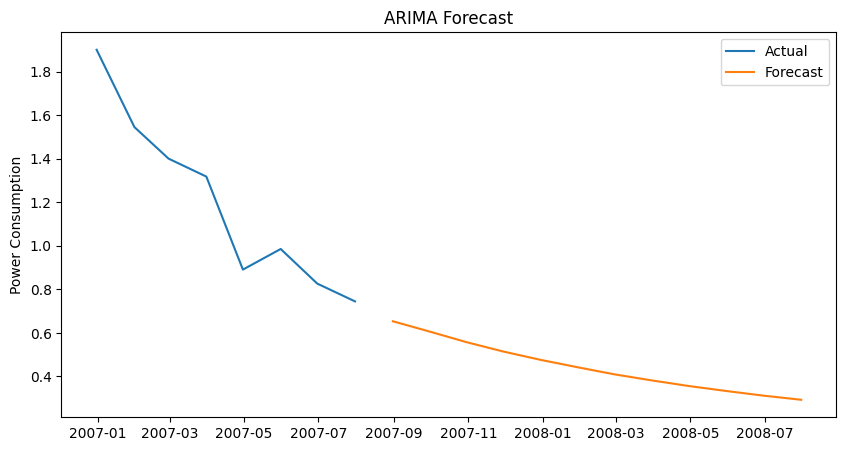

In [31]:
# ARIMA Forecast -- The ARIMA model predicts a stable future trend with minor fluctuations in electricity consumption.
from statsmodels.tsa.arima.model import ARIMA

ts_log = np.log(ts)

model = ARIMA(ts_log, order=(2,1,2))
model_fit = model.fit()

forecast_log = model_fit.forecast(steps=12)
forecast = np.exp(forecast_log)

plt.figure(figsize=(10,5))
plt.plot(ts, label='Actual')
plt.plot(forecast.index, forecast, label='Forecast')
plt.legend()
plt.title("ARIMA Forecast")
plt.ylabel("Power Consumption")
plt.show()

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 5.
/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1875: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


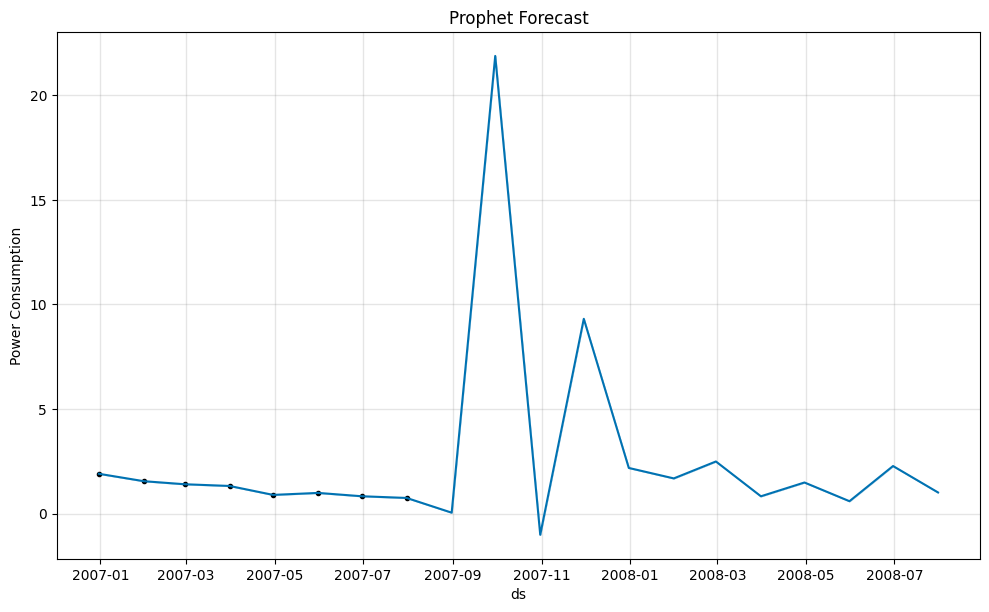

In [32]:
# PROPHET -- Prophet captures both trend and seasonality effectively, providing a smooth and interpretable forecast.
from prophet import Prophet

prophet_df = ts.reset_index()
prophet_df.columns = ['ds', 'y']

model = Prophet(yearly_seasonality=True)
model.fit(prophet_df)

future = model.make_future_dataframe(periods=12, freq='M')
forecast = model.predict(future)

fig = model.plot(forecast)
plt.title("Prophet Forecast")
plt.ylabel("Power Consumption")
plt.show()

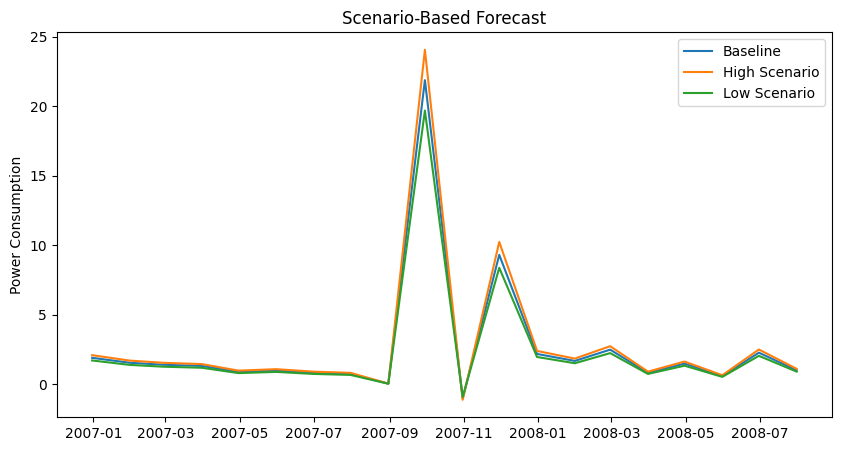

In [33]:
# SCENARIO MODELING
#Scenario modeling demonstrates how electricity demand may vary under different assumptions, aiding planning and decision-making.
forecast['high'] = forecast['yhat'] * 1.1
forecast['low'] = forecast['yhat'] * 0.9

plt.figure(figsize=(10,5))
plt.plot(forecast['ds'], forecast['yhat'], label='Baseline')
plt.plot(forecast['ds'], forecast['high'], label='High Scenario')
plt.plot(forecast['ds'], forecast['low'], label='Low Scenario')
plt.legend()
plt.title("Scenario-Based Forecast")
plt.ylabel("Power Consumption")
plt.show()